# US-02: Manejo fluido de NumPy y Pandas

Análisis exploratorio usando NumPy para operaciones vectoriales, Pandas para manipulación de datos y Matplotlib para visualización.
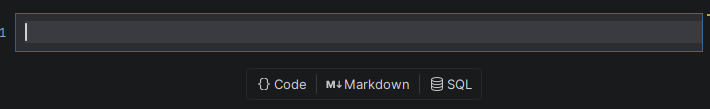

## 1. NumPy — Arrays y operaciones vectoriales

In [1]:
import numpy as np

# Crear arrays
a = np.array([1, 2, 3, 4, 5])
b = np.array([10, 20, 30, 40, 50])

print("Array a:", a)
print("Array b:", b)
print("Suma:", a + b)
print("Multiplicación:", a * b)
print("Forma:", a.shape)
print("Tipo de dato:", a.dtype)

Array a: [1 2 3 4 5]
Array b: [10 20 30 40 50]
Suma: [11 22 33 44 55]
Multiplicación: [ 10  40  90 160 250]
Forma: (5,)
Tipo de dato: int64


In [2]:
# Array 2D (matriz)
matriz = np.array([[1, 2, 3],
                   [4, 5, 6],
                   [7, 8, 9]])

print("Matriz:\n", matriz)
print("Forma:", matriz.shape)       # filas x columnas
print("Elemento [0,0]:", matriz[0, 0])  # primera fila, primera columna
print("Elemento [1,2]:", matriz[1, 2])  # segunda fila, tercera columna
print("Primera fila:", matriz[0, :])
print("Segunda columna:", matriz[:, 1])

Matriz:
 [[1 2 3]
 [4 5 6]
 [7 8 9]]
Forma: (3, 3)
Elemento [0,0]: 1
Elemento [1,2]: 6
Primera fila: [1 2 3]
Segunda columna: [2 5 8]


In [3]:
# Operaciones estadísticas
print("Suma total:", matriz.sum())
print("Promedio:", matriz.mean())
print("Valor máximo:", matriz.max())
print("Valor mínimo:", matriz.min())

# Reshape: cambiar la forma sin cambiar los datos
vector = np.array([1, 2, 3, 4, 5, 6])
matriz_2x3 = vector.reshape(2, 3)
print("\nVector original:", vector)
print("Convertido a 2x3:\n", matriz_2x3)

Suma total: 45
Promedio: 5.0
Valor máximo: 9
Valor mínimo: 1

Vector original: [1 2 3 4 5 6]
Convertido a 2x3:
 [[1 2 3]
 [4 5 6]]


## 2. Pandas — Manipulación de datos

In [4]:
import pandas as pd

# Crear un DataFrame (tabla de datos)
datos = {
    "nombre": ["Ana", "Luis", "María", "Carlos"],
    "edad":   [23, 35, 28, 41],
    "ciudad": ["Madrid", "Lima", "Bogotá", "Madrid"],
    "salario": [3000, 4500, 3800, 5200]
}

df = pd.DataFrame(datos)
print(df)

   nombre  edad  ciudad  salario
0     Ana    23  Madrid     3000
1    Luis    35    Lima     4500
2   María    28  Bogotá     3800
3  Carlos    41  Madrid     5200


In [5]:
# Explorar el DataFrame
print("Forma:", df.shape)           # cuántas filas y columnas
print("\nPrimeras filas:\n", df.head(2))
print("\nResumen estadístico:\n", df.describe())
print("\nFiltrar mayores de 30:\n", df[df["edad"] > 30])
print("\nOrdenar por salario:\n", df.sort_values("salario", ascending=False))

Forma: (4, 4)

Primeras filas:
   nombre  edad  ciudad  salario
0    Ana    23  Madrid     3000
1   Luis    35    Lima     4500

Resumen estadístico:
             edad      salario
count   4.000000     4.000000
mean   31.750000  4125.000000
std     7.889867   942.956344
min    23.000000  3000.000000
25%    26.750000  3600.000000
50%    31.500000  4150.000000
75%    36.500000  4675.000000
max    41.000000  5200.000000

Filtrar mayores de 30:
    nombre  edad  ciudad  salario
1    Luis    35    Lima     4500
3  Carlos    41  Madrid     5200

Ordenar por salario:
    nombre  edad  ciudad  salario
3  Carlos    41  Madrid     5200
1    Luis    35    Lima     4500
2   María    28  Bogotá     3800
0     Ana    23  Madrid     3000


In [6]:
# Agrupar por ciudad
print("Promedio de salario por ciudad:")
print(df.groupby("ciudad")["salario"].mean())

# Agregar una columna nueva
df["salario_mensual"] = df["salario"] / 12
print("\nDataFrame con nueva columna:\n", df)

# Simular datos faltantes y limpiarlos
df_con_nulos = df.copy()
df_con_nulos.loc[1, "salario"] = None
print("\nCon dato faltante:\n", df_con_nulos["salario"])
print("\nRelleno con promedio:", df_con_nulos["salario"].fillna(df_con_nulos["salario"].mean()))

Promedio de salario por ciudad:
ciudad
Bogotá    3800.0
Lima      4500.0
Madrid    4100.0
Name: salario, dtype: float64

DataFrame con nueva columna:
    nombre  edad  ciudad  salario  salario_mensual
0     Ana    23  Madrid     3000       250.000000
1    Luis    35    Lima     4500       375.000000
2   María    28  Bogotá     3800       316.666667
3  Carlos    41  Madrid     5200       433.333333

Con dato faltante:
 0    3000.0
1       NaN
2    3800.0
3    5200.0
Name: salario, dtype: float64

Relleno con promedio: 0    3000.0
1    4000.0
2    3800.0
3    5200.0
Name: salario, dtype: float64


## 3. Matplotlib — Visualización

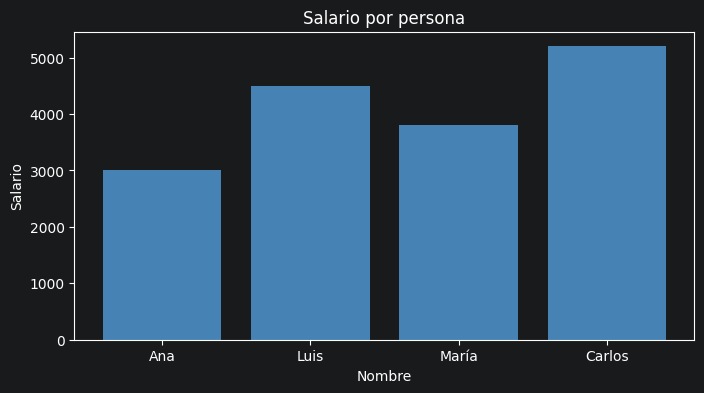

In [7]:
import matplotlib.pyplot as plt

# Gráfica de barras: salario por persona
plt.figure(figsize=(8, 4))
plt.bar(df["nombre"], df["salario"], color="steelblue")
plt.title("Salario por persona")
plt.xlabel("Nombre")
plt.ylabel("Salario")
plt.show()

## 4. Ejercicio final — Análisis exploratorio del dataset Iris

In [8]:
from sklearn.datasets import load_iris

# Cargar el dataset
iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris["especie"] = pd.Categorical.from_codes(iris.target, iris.target_names)

print("Forma:", df_iris.shape)
print("\nPrimeras filas:\n", df_iris.head())
print("\nEspecies:", df_iris["especie"].value_counts())

Forma: (150, 5)

Primeras filas:
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  especie  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

Especies: especie
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [9]:
# Estadísticas agrupadas por especie
print(df_iris.groupby("especie").mean().round(2))

            sepal length (cm)  sepal width (cm)  petal length (cm)  \
especie                                                              
setosa                   5.01              3.43               1.46   
versicolor               5.94              2.77               4.26   
virginica                6.59              2.97               5.55   

            petal width (cm)  
especie                       
setosa                  0.25  
versicolor              1.33  
virginica               2.03  


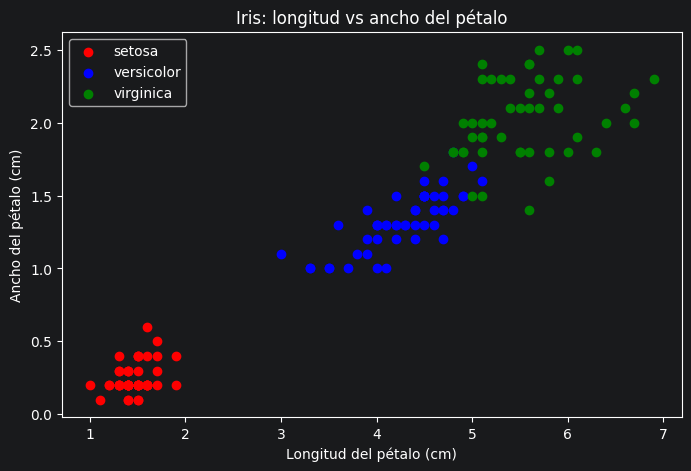

In [10]:
# Gráfica de dispersión: longitud vs ancho del pétalo
colores = {"setosa": "red", "versicolor": "blue", "virginica": "green"}

plt.figure(figsize=(8, 5))
for especie, grupo in df_iris.groupby("especie"):
    plt.scatter(grupo["petal length (cm)"],
                grupo["petal width (cm)"],
                label=especie,
                color=colores[especie])

plt.title("Iris: longitud vs ancho del pétalo")
plt.xlabel("Longitud del pétalo (cm)")
plt.ylabel("Ancho del pétalo (cm)")
plt.legend()
plt.show()

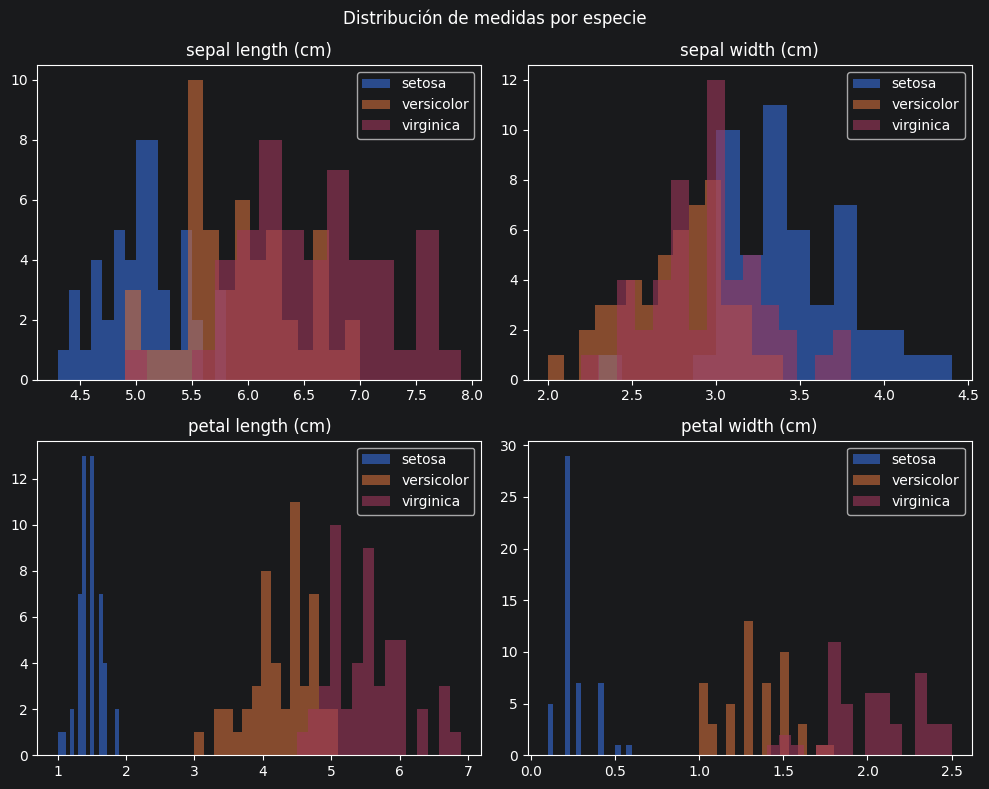

In [11]:
# Histograma de distribución por especie
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
columnas = ["sepal length (cm)", "sepal width (cm)",
            "petal length (cm)", "petal width (cm)"]

for ax, columna in zip(axes.flatten(), columnas):
    for especie, grupo in df_iris.groupby("especie"):
        ax.hist(grupo[columna], alpha=0.6, label=especie, bins=15)
    ax.set_title(columna)
    ax.legend()

plt.suptitle("Distribución de medidas por especie")
plt.tight_layout()
plt.show()

## Glosario

| Término | Definición |
|---|---|
| **Array** | Estructura de datos de NumPy para almacenar números. A diferencia de una lista de Python, permite operaciones matemáticas directas sin usar bucles. |
| **Array 1D** | Array de una sola dimensión, equivale a un vector. Ej: `[1, 2, 3, 4, 5]` |
| **Array 2D** | Array de dos dimensiones, equivale a una matriz con filas y columnas. Ej: una tabla de datos. |
| **shape** | Indica la forma del array — cuántas filas y columnas tiene. Ej: `(3, 3)` = 3 filas y 3 columnas. |
| **dtype** | Tipo de dato del array. Ej: `int64` para enteros, `float64` para decimales. |
| **reshape** | Cambia la forma del array sin modificar sus datos. Ej: un vector de 6 elementos puede convertirse en una matriz 2x3. |
| **Broadcasting** | Capacidad de NumPy de operar arrays de distintas formas automáticamente, sin necesidad de que tengan el mismo tamaño. |
| **DataFrame** | Estructura principal de Pandas. Es una tabla de datos con filas numeradas y columnas con nombre, similar a una hoja de Excel. |
| **head()** | Muestra las primeras filas de un DataFrame. Útil para explorar datasets grandes rápidamente. |
| **describe()** | Genera un resumen estadístico automático del DataFrame: conteo, promedio, desviación estándar, mínimo, máximo y percentiles. |
| **groupby()** | Agrupa filas por una columna y aplica una operación sobre cada grupo. Equivale al GROUP BY de SQL. |
| **fillna()** | Rellena valores faltantes (NaN) con un valor definido. En IA lo más común es rellenar con el promedio de la columna. |
| **NaN** | "Not a Number" — representa un valor faltante en un DataFrame. Es muy común en datasets reales. |
| **Filtrado** | Seleccionar filas de un DataFrame que cumplan una condición. Ej: `df[df["edad"] > 30]` |
| **sort_values()** | Ordena el DataFrame por una columna de forma ascendente o descendente. |
| **Matplotlib** | Librería de Python para crear gráficas. Permite visualizar datos con barras, líneas, scatter plots, histogramas, etc. |
| **Scatter plot** | Gráfica de dispersión — muestra la relación entre dos variables numéricas. Cada punto representa una muestra. |
| **Histograma** | Gráfica que muestra cómo se distribuyen los valores de una variable — cuántas veces aparece cada rango de valores. |
| **Dataset Iris** | Dataset clásico de ML con 150 flores de 3 especies, cada una con 4 medidas. Es el "hola mundo" del análisis de datos. |
| **Análisis exploratorio (EDA)** | Proceso de examinar un dataset con estadísticas y visualizaciones antes de entrenar un modelo, para entender su estructura y distribución. |